# DLinear + BERT — Naive Multimodal Baseline

**Purpose:** Establish whether adding text (BioLinkBERT) on top of DLinear improves over
DLinear-alone, without any sophisticated cross-modal attention.
This is the direct multimodal counterpart to the unimodal DLinear baseline.

**Fusion strategy (naive):**
- DLinear encodes the numerical sequence → numerical forecast `(B, H)`
- BioLinkBERT encodes each of the 36 weekly texts → CLS embeddings → mean-pool across time → text context `(B, 768)`
- Text context is projected linearly → `(B, H)`
- Both contributions are summed element-wise → final prediction `(B, H)`

No CMA, no temporal transformer — just linear projection of BERT pooled output added to DLinear.  
This isolates the value of DSA's cross-modal attention and temporal modeling.

**Exact same pipeline as `time-mmd-new-beginning_stable_` (V17):**
- Data: `US_FLURATIO_Week.csv` (MM-TSFlib)
- Text: `Final_Search_6` (facts) 
- Tokenizer: `michiyasunaga/BioLinkBERT-base`, `max_len=256`
- Split: 80 / 10 / 10 chronological
- Lookback: 36 | Horizon: 12


## 1. Dependencies

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Added for offline HF access
import os
# os.environ["TRANSFORMERS_OFFLINE"] = "1"
# os.environ["HF_DATASETS_OFFLINE"] = "1"

# # Disable Hugging Face Hub internet access
# os.environ["HF_HUB_OFFLINE"] = "1"

import math
import random
import os
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from tqdm import tqdm
import matplotlib as mpl
from matplotlib.patches import Patch
import matplotlib.pyplot as plt
from torch.cuda.amp import autocast, GradScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_cosine_schedule_with_warmup

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


Device: cuda


## 2. Config — Edit paths here

In [3]:
# ── Edit these two paths ──────────────────────────────────────────────────────
DATA_PATH = '/kaggle/input/datasets/mohammadhossein77/ili-data/US_FLURATIO_Week.csv'
LOG_DIR   = '/kaggle/working/logs'
# ─────────────────────────────────────────────────────────────────────────────

os.makedirs(LOG_DIR, exist_ok=True)

LOOKBACK           = 36
HORIZON            = 12
MAX_LEN            = 256    # same as DSA stable nb
BATCH_SIZE         = 4      # BERT is large; keep small and use accumulation
ACCUMULATION_STEPS = 4      # effective batch = 4 * 8 = 32 (same order as DSA)
EPOCHS             = 120     # same as DSA stable nb
PATIENCE           = 10     # same as DSA stable nb
WARMUP_EPOCHS      = 10      # same as DSA stable nb
BERT_LR            = 1e-5   # same as DSA stable nb
OTHER_LR           = 1e-5   # same as DSA stable nb
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## 3. Data Loading & Feature Engineering

Identical to `time-mmd-new-beginning_stable_` cells 20–63.

In [4]:
df = pd.read_csv(DATA_PATH)
print(f'Raw shape: {df.shape}')
df.head(3)

Raw shape: (1389, 25)


,date,start_date,end_date,REGION TYPE,REGION,YEAR,WEEK,% WEIGHTED ILI,OT,AGE 0-4,...,ILITOTAL,NUM. OF PROVIDERS,TOTAL PATIENTS,YEAR_WEEK,prior_history_avg,prior_history_std,Final_Search_2,Final_Search_4,Final_Search_6,Final_Output
0,9/29/1997,9/29/1997,10/5/1997,National,X,1997,40,1.10148,1.21686,179,...,570,192,46842,1997-40,0.0,0.0,Available facts are as follows: 1997-09-22: Za...,Available facts are as follows: 1997-09-22: Za...,Available facts are as follows: 1997-09-22: Za...,"Based on the provided textual information, I p..."
1,10/6/1997,10/6/1997,10/12/1997,National,X,1997,41,1.20007,1.28064,199,...,615,191,48023,1997-41,0.0,0.0,Available facts are as follows: 1997-09-29: Th...,Available facts are as follows: 1997-09-29: Th...,Available facts are as follows: 1997-09-29: Th...,"Based on the provided textual information, my ..."
2,10/13/1997,10/13/1997,10/19/1997,National,X,1997,42,1.37876,1.23906,228,...,681,219,54961,1997-42,0.0,0.0,Available facts are as follows: 1997-10-06: Th...,Available facts are as follows: 1997-10-06: Th...,Available facts are as follows: 1997-10-06: Th...,"Based on the available textual information, I ..."


In [5]:
# ── Text columns (last 4) — same as stable nb cell 29 & 32 ───────────────────
text_df = pd.DataFrame()
text_df['facts'] = df['Final_Search_6']
# text_df['preds'] = df['Final_Output']

# ── Numerical columns — same as stable nb cells 20-63 ────────────────────────
numeric_df = df.iloc[:, :-4].copy()
numeric_df.drop(['date'], axis=1, inplace=True, errors='ignore')
numeric_df['start_date'] = pd.to_datetime(numeric_df['start_date'])
numeric_df['end_date']   = pd.to_datetime(numeric_df['end_date'])

# Cyclic week encoding
numeric_df['WEEK_sin'] = np.sin(2 * np.pi * (numeric_df['WEEK'] / 52))
numeric_df['WEEK_cos'] = np.cos(2 * np.pi * (numeric_df['WEEK'] / 52))
numeric_df.drop(['WEEK'], axis=1, inplace=True)

# Drop redundant columns
numeric_df.drop(['REGION TYPE', 'REGION', 'YEAR_WEEK'], axis=1, inplace=True, errors='ignore')
numeric_df.drop(['prior_history_std', 'prior_history_avg'], axis=1, inplace=True, errors='ignore')

# Replace X, coerce to numeric
numeric_df = numeric_df.replace('X', np.nan)

num_features = [
    'YEAR', 'WEEK_sin', 'WEEK_cos',
    '% WEIGHTED ILI',
    'AGE 0-4', 'AGE 5-24',
    'AGE 25-49', 'AGE 25-64', 'AGE 50-64', 'AGE 65',
    'ILITOTAL', 'NUM. OF PROVIDERS', 'TOTAL PATIENTS'
]
numeric_df[num_features] = numeric_df[num_features].apply(pd.to_numeric, errors='coerce')

# Merge numerical + text on index (aligned by construction)
merged_df = pd.concat([numeric_df, text_df], axis=1)

print(f'Merged shape: {merged_df.shape}')
merged_df.head(3)

Merged shape: (1389, 17)


,start_date,end_date,YEAR,% WEIGHTED ILI,OT,AGE 0-4,AGE 25-49,AGE 25-64,AGE 5-24,AGE 50-64,AGE 65,ILITOTAL,NUM. OF PROVIDERS,TOTAL PATIENTS,WEEK_sin,WEEK_cos,facts
0,1997-09-29,1997-10-05,1997,1.10148,1.21686,179,NaN,157.0,205,NaN,29,570,192,46842,-0.992709,0.120537,Available facts are as follows: 1997-09-22: Za...
1,1997-10-06,1997-10-12,1997,1.20007,1.28064,199,NaN,151.0,242,NaN,23,615,191,48023,-0.970942,0.239316,Available facts are as follows: 1997-09-29: Th...
2,1997-10-13,1997-10-19,1997,1.37876,1.23906,228,NaN,153.0,266,NaN,34,681,219,54961,-0.935016,0.354605,Available facts are as follows: 1997-10-06: Th...


## 4. Chronological Split (80 / 10 / 10)

In [6]:
merged_df.sort_values('start_date', inplace=True)

n          = len(merged_df)
train_size = int(n * 0.8)
val_size   = int(n * 0.1)

train_df = merged_df.iloc[:train_size].copy()
val_df   = merged_df.iloc[train_size : train_size + val_size].copy()
test_df  = merged_df.iloc[train_size + val_size:].copy()

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

Train: 1111 | Val: 138 | Test: 140


In [7]:
# # here we should add the cylic featuers

# # New cyclic features ....
# def add_trend_features(df):
#     df = df.copy()
#     # # 1. Week-over-week change
#     # df["OT_diff_1"] = df["OT"].diff() # positive -> outbreak increasing (Vice-Versa)
    
#     # # 2. Rooling average of OT rate
#     # df["OT_roll_mean_3"] = df["OT"].rolling(window=3).mean()
#     df["OT_roll_mean_36"] = df["OT"].rolling(window=36).mean()
    
#     # # 3. Rooling standard deviation of OT rate
#     # df["OT_roll_std_3"] = df["OT"].rolling(window=3).std()
#     df["OT_roll_std_36"] = df["OT"].rolling(window=36).std()
    
#     # # 4. Momentun rate
#     # df["OT_momentum_3"] = df["OT"] - df["OT"].shift(3)
#     # df["OT_momentum_6"] = df["OT"] - df["OT"].shift(6)

#     # # 5. Relative Surge Feature
#     # df["OT_relative_6"] = (df["OT"] / df["OT_roll_mean_6"] + 1e-6) ## to not introduce new feature, I decided to rewrite it
#     # df["OT_relative_6"] = (df["OT"] / (df["OT"].rooling(window=6).mean() + 1e-6)) 

#     # # 6. Acceleration feature
#     # df["OT_acceleration"] = df["OT_diff_1"].diff(1) 
#     df = df.fillna(0)

#     return df

 

In [8]:
# # Update -------------------------
# train_df = add_trend_features(train_df)
# val_df = add_trend_features(val_df)
# test_df = add_trend_features(test_df)



In [9]:
# num_features.extend(["OT_roll_mean_36", "OT_roll_std_36"])
# num_features

## 5. AGE Imputation (post-split, pre-scale)

Identical to stable nb cell 67.

In [10]:
for dff in [train_df, val_df, test_df]:
    mask_split = (dff['AGE 25-49'].isna() & dff['AGE 50-64'].isna() & ~dff['AGE 25-64'].isna())
    dff.loc[mask_split, 'AGE 25-49'] = dff.loc[mask_split, 'AGE 25-64'] * 0.6
    dff.loc[mask_split, 'AGE 50-64'] = dff.loc[mask_split, 'AGE 25-64'] * 0.4

    mask_comb = (~dff['AGE 25-49'].isna() & ~dff['AGE 50-64'].isna() & dff['AGE 25-64'].isna())
    dff.loc[mask_comb, 'AGE 25-64'] = dff.loc[mask_comb, 'AGE 25-49'] + dff.loc[mask_comb, 'AGE 50-64']

print('NaNs after imputation (train):')
print(train_df[num_features].isna().sum())

NaNs after imputation (train):
YEAR                 0
WEEK_sin             0
WEEK_cos             0
% WEIGHTED ILI       0
AGE 0-4              0
AGE 5-24             0
AGE 25-49            0
AGE 25-64            0
AGE 50-64            0
AGE 65               0
ILITOTAL             0
NUM. OF PROVIDERS    0
TOTAL PATIENTS       0
dtype: int64


## 6. Scaling (fit on train only)

Identical to stable nb cell 72.

In [11]:
feature_scaler = MinMaxScaler()
train_df[num_features] = feature_scaler.fit_transform(train_df[num_features])
val_df[num_features]   = feature_scaler.transform(val_df[num_features])
test_df[num_features]  = feature_scaler.transform(test_df[num_features])
joblib.dump(feature_scaler, os.path.join(LOG_DIR, 'dlinear_bert_feature_scaler.pkl'))

target_scaler = MinMaxScaler()
train_df['OT'] = target_scaler.fit_transform(train_df['OT'].values.reshape(-1, 1)).flatten()
val_df['OT']   = target_scaler.transform(val_df['OT'].values.reshape(-1, 1)).flatten()
test_df['OT']  = target_scaler.transform(test_df['OT'].values.reshape(-1, 1)).flatten()
joblib.dump(target_scaler, os.path.join(LOG_DIR, 'dlinear_bert_target_scaler.pkl'))

num_features.append('OT')
print(f'Total numerical features (incl. OT): {len(num_features)}')

Total numerical features (incl. OT): 14


## 7. Sequence Construction

Returns both numerical arrays and text lists per sample.  
Identical lookback-tail prepending to stable nb cell 76.

In [12]:
def create_sequences(df, lookback, horizon):
    """Returns X_num (N, lookback, C), X_text (N, lookback) list-of-strings, y (N, horizon)."""
    
    df = df.sort_values('start_date').reset_index(drop=True)
    X_num, X_text, y = [], [], []
    for i in range(len(df) - lookback - horizon + 1):
        X_num.append(df[num_features].iloc[i : i + lookback].values)       # (36, 14)
        # Same concatenation as stable nb cell 75
        text_seq = (
            df['facts'].iloc[i : i + lookback] 
            # + ' ' +
            # df['preds'].iloc[i : i + lookback]
        ).tolist()
        X_text.append(text_seq)                                             # list of 36 strings
        y.append(df['OT'].iloc[i + lookback : i + lookback + horizon].values)
    return np.array(X_num, dtype=np.float32), np.array(X_text, dtype=object), np.array(y, dtype=np.float32)



val_df_full  = pd.concat([train_df.iloc[-LOOKBACK:], val_df],  ignore_index=True)
test_df_full = pd.concat([val_df.iloc[-LOOKBACK:],  test_df],  ignore_index=True)

X_num_train, X_text_train, y_train = create_sequences(train_df,     LOOKBACK, HORIZON)
X_num_val,   X_text_val,   y_val   = create_sequences(val_df_full,  LOOKBACK, HORIZON)
X_num_test,  X_text_test,  y_test  = create_sequences(test_df_full, LOOKBACK, HORIZON)

print(f'Train : {X_num_train.shape} | {X_text_train.shape} -> {y_train.shape}')
print(f'Val   : {X_num_val.shape}   | {X_text_val.shape}   -> {y_val.shape}')
print(f'Test  : {X_num_test.shape}  | {X_text_test.shape}  -> {y_test.shape}')

Train : (1064, 36, 14) | (1064, 36) -> (1064, 12)
Val   : (127, 36, 14)   | (127, 36)   -> (127, 12)
Test  : (129, 36, 14)  | (129, 36)  -> (129, 12)


## 8. Tokenization

Same tokenizer and `max_len=256` as stable nb cell 84.

In [13]:
def tokenize_sequences(sequences, tokenizer, max_len=256):
    """Tokenizes each sample's 36-week text list.
    Returns a list of dicts: [{'input_ids': (36, L), 'attention_mask': (36, L)}, ...]
    """
    tokenized = []
    for sample in tqdm(sequences, desc='Tokenizing'):
        enc = tokenizer(
            sample.tolist(),
            max_length=max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        tokenized.append({
            'input_ids':      enc['input_ids'],       # (36, 256)
            'attention_mask': enc['attention_mask']   # (36, 256)
        })
    return tokenized


tokenizer = AutoTokenizer.from_pretrained('michiyasunaga/BioLinkBERT-base')

X_text_train_tok = tokenize_sequences(X_text_train, tokenizer, MAX_LEN)
X_text_val_tok   = tokenize_sequences(X_text_val,   tokenizer, MAX_LEN)
X_text_test_tok  = tokenize_sequences(X_text_test,  tokenizer, MAX_LEN)

print(f'Train samples tokenized: {len(X_text_train_tok)}')
print(f'Per-sample token shape : {X_text_train_tok[0]["input_ids"].shape}')  # (36, 256)

config.json:   0%|          | 0.00/559 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/379 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizing: 100%|██████████| 129/129 [00:05<00:00, 22.63it/s]

Train samples tokenized: 1064
Per-sample token shape : torch.Size([36, 256])


## 9. Dataset & DataLoader

In [14]:
class MultimodalDataset(Dataset):
    """Same structure as CustomDataset in stable nb cell 85."""
    def __init__(self, X_num, X_text_tok, y):
        self.X_num     = torch.tensor(X_num, dtype=torch.float32)
        self.X_text    = X_text_tok
        self.y         = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X_num)

    def __getitem__(self, idx):
        return self.X_num[idx], self.X_text[idx], self.y[idx]


train_loader = DataLoader(MultimodalDataset(X_num_train, X_text_train_tok, y_train),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(MultimodalDataset(X_num_val,   X_text_val_tok,   y_val),
                          batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(MultimodalDataset(X_num_test,  X_text_test_tok,  y_test),
                          batch_size=BATCH_SIZE, shuffle=False)

print(f'Batches — Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Batches — Train: 266 | Val: 32 | Test: 33


## 10. Model: DLinear + BERT (Naive Fusion)

**Architecture:**
```
Numerical path : DLinear(lookback=36 → horizon=12)  →  num_out  (B, 12)
Text path      : BioLinkBERT → CLS per week → mean over 36 weeks → Linear(768→12)  →  text_out  (B, 12)
Output         : num_out + text_out  →  (B, 12)
```

No CMA, no temporal transformer — this is intentionally naive to serve as a fair baseline.
It answers: *does text help DLinear at all, without sophisticated fusion?*

In [15]:
# ── DLinear sub-modules (identical to unimodal DLinear baseline) ───────────────

class MovingAvg(nn.Module):
    """Official DLinear moving average — identical to unimodal baseline."""
    def __init__(self, kernel_size, stride=1):
        super().__init__()
        self.kernel_size = kernel_size
        self.avg = nn.AvgPool1d(kernel_size=kernel_size, stride=stride, padding=0)

    def forward(self, x):
        front = x[:, 0:1, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        end   = x[:, -1:, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        x = torch.cat([front, x, end], dim=1)
        x = self.avg(x.permute(0, 2, 1))
        return x.permute(0, 2, 1)


class SeriesDecomp(nn.Module):
    def __init__(self, kernel_size):
        super().__init__()
        self.moving_avg = MovingAvg(kernel_size)

    def forward(self, x):
        trend    = self.moving_avg(x)
        seasonal = x - trend
        return seasonal, trend


# ── Full multimodal model ──────────────────────────────────────────────────────

class DLinearBERT(nn.Module):
    """
    Naive multimodal baseline:
      - DLinear for numerical forecasting
      - BioLinkBERT for text encoding (partially unfrozen, same as DSA)
      - Simple sum fusion (no cross-modal attention)
    """
    def __init__(self, lookback, horizon, num_channels, kernel_size=25):
        super().__init__()

        # ── Numerical path (DLinear) ─────────────────────────────────────────
        self.decomp          = SeriesDecomp(kernel_size)
        self.linear_seasonal = nn.Linear(lookback, horizon)
        self.linear_trend    = nn.Linear(lookback, horizon)

        # Official weight init: uniform 1/seq_len
        self.linear_seasonal.weight = nn.Parameter(
            (1 / lookback) * torch.ones([horizon, lookback]))
        self.linear_trend.weight = nn.Parameter(
            (1 / lookback) * torch.ones([horizon, lookback]))

        # ── Text path (BioLinkBERT) ──────────────────────────────────────────
        self.bert = AutoModel.from_pretrained(
            'michiyasunaga/BioLinkBERT-base'
            # force_download=False,
            # resume_download=True
        )

        # Freeze all layers 
        for param in self.bert.parameters():
            param.requires_grad = False 
        # for param in self.bert.encoder.layer[-8:].parameters():
        #     param.requires_grad = True

        # Project pooled BERT output (768) → horizon
        # This is the ONLY text-to-output path — no temporal modeling
        self.text_proj = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(256, horizon)
        )

        self.num_channels = num_channels
        self.ot_idx       = num_channels - 1  # OT is last column
        self.text_gate = nn.Parameter(torch.tensor(0.1)) # Near zero intialized


    def forward(self, X_num, input_ids, attention_mask):
        """
        X_num          : (B, T, C)      numerical sequence
        input_ids      : (B, T, L)      tokenized text for each of the T weeks
        attention_mask : (B, T, L)
        Returns        : (B, horizon)
        """
        B, T, L = input_ids.shape

        # ── Numerical path ───────────────────────────────────────────────────
        seasonal, trend = self.decomp(X_num)                    # each (B, T, C)
        # Permute so Linear maps across T per channel
        seasonal_out = self.linear_seasonal(seasonal.permute(0, 2, 1))  # (B, C, H)
        trend_out    = self.linear_trend(trend.permute(0, 2, 1))        # (B, C, H)
        num_out = (seasonal_out + trend_out)[:, self.ot_idx, :]  # (B, H) — OT channel only

        # ── Text path ────────────────────────────────────────────────────────
        # Flatten weeks into batch for BERT
        flat_ids  = input_ids.view(B * T, L)
        flat_mask = attention_mask.view(B * T, L)

        bert_out  = self.bert(input_ids=flat_ids, attention_mask=flat_mask)
        cls_emb   = bert_out.last_hidden_state[:, 0, :]  # (B*T, 768) — CLS token
        cls_emb   = cls_emb.view(B, T, 768)              # (B, T, 768)

        # Mean-pool across the 36 weeks → single context vector per sample
        text_ctx  = cls_emb.mean(dim=1)                  # (B, 768)
        text_out  = self.text_proj(text_ctx)              # (B, H)

        # Added to have exact comparison with CMA
        return num_out + self.text_gate * text_out

        ## ── Naive fusion: element-wise sum ────────────────────────────────────
        # return num_out + text_out                         # (B, H)

## 11. Training Loop

In [16]:
NUM_CHANNELS = X_num_train.shape[-1]  # 14

model = DLinearBERT(
    lookback=LOOKBACK,
    horizon=HORIZON,
    num_channels=NUM_CHANNELS,
    kernel_size=25
).to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / Total: {total:,}')

# Same optimizer split as DSA stable nb cell 101
bert_params     = list(model.bert.parameters())
bert_param_ids  = {id(p) for p in bert_params}
gate_params  = [model.text_gate]
gate_param_ids = {id(model.text_gate)}
other_params    = [p for p in model.parameters() if id(p) not in bert_param_ids and id(p) not in gate_param_ids]

optimizer = torch.optim.AdamW([
    {'params': bert_params,  'lr': BERT_LR,  'weight_decay': 1e-4},
    {'params': other_params, 'lr': OTHER_LR, 'weight_decay': 1e-4},
    {'params': gate_params,  'lr': OTHER_LR, 'weight_decay': 0.0},
])

# # No need for seprate lr considering the bert is frozen
# optimizer = torch.optim.AdamW(
#     [p for p in model.parameters() if p.requires_grad],
#     lr=OTHER_LR,
#     weight_decay=1e-4
# )

## This part is problematic due to step values ..............
# scheduler = get_cosine_schedule_with_warmup(
#     optimizer,
#     num_warmup_steps=WARMUP_EPOCHS * len(train_loader),
#     num_training_steps=EPOCHS * len(train_loader)
# )

updates_per_epoch   = math.ceil(len(train_loader) / ACCUMULATION_STEPS)
scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps  = WARMUP_EPOCHS * updates_per_epoch,
    num_training_steps = EPOCHS * updates_per_epoch
)

criterion   = nn.MSELoss()
amp_scaler  = GradScaler()

history         = {'epoch': [], 'train_loss': [], 'val_loss': []}
best_val_loss   = float('inf')
best_model_path = None
p_counter       = 0
best_model_path = os.path.join(LOG_DIR, 'dlinear_bert_best.pth')  # fixed name


for epoch in tqdm(range(EPOCHS)):

    # ── Train ──────────────────────────────────────────────────────────────────
    model.train()
    optimizer.zero_grad()
    epoch_train_loss = 0.0

    for batch_idx, batch in enumerate(train_loader):
        X_num_b  = batch[0].to(device)
        text_b   = {k: v.to(device) for k, v in batch[1].items()}
        targets  = batch[2].to(device)

        with autocast():
            preds = model(
                X_num_b,
                text_b['input_ids'],
                text_b['attention_mask']
            )
            loss = criterion(preds, targets) / ACCUMULATION_STEPS

        amp_scaler.scale(loss).backward()

        if (batch_idx + 1) % ACCUMULATION_STEPS == 0 or (batch_idx + 1) == len(train_loader):
            amp_scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            amp_scaler.step(optimizer)
            amp_scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        epoch_train_loss += loss.item() * ACCUMULATION_STEPS

    avg_train = epoch_train_loss / len(train_loader)

    # ── Validate ───────────────────────────────────────────────────────────────
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            X_num_b = batch[0].to(device)
            text_b  = {k: v.to(device) for k, v in batch[1].items()}
            targets = batch[2].to(device)
            with autocast():
                preds    = model(X_num_b, text_b['input_ids'], text_b['attention_mask'])
                val_loss += criterion(preds, targets).item()

    avg_val = val_loss / len(val_loader)

    history['epoch'].append(epoch)
    history['train_loss'].append(avg_train)
    history['val_loss'].append(avg_val)

    
    ## To prevent storage issue)
    ## overwrite the same file (keep only the best)
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        p_counter = 0
        print(f"A NEW BEST MODEL at EPOCH: {epoch}")
        torch.save(model.state_dict(), best_model_path)  
    
    else:
        if epoch >= WARMUP_EPOCHS:
            p_counter += 1
            if p_counter >= PATIENCE:
                print(f'Early stopping at epoch {epoch}')
                break

    if epoch % 5 == 0 or epoch < 5:
        print(f'Epoch {epoch:3d} | Train: {avg_train:.6f} | Val: {avg_val:.6f}')
        print(f'  text_gate = {model.text_gate.item():.4f}')

print(f'\nBest val loss : {best_val_loss:.6f}')
print(f'Checkpoint    : {best_model_path}')

pytorch_model.bin:   0%|          | 0.00/433M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: michiyasunaga/BioLinkBERT-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Trainable params: 200,837 / Total: 108,433,541


...

A NEW BEST MODEL at EPOCH: 117



 98%|█████████▊| 118/120 [5:30:03<05:36, 168.15s/it]

A NEW BEST MODEL at EPOCH: 118



100%|██████████| 120/120 [5:35:37<00:00, 167.82s/it]


Best val loss : 0.039387
Checkpoint    : /kaggle/working/logs/dlinear_bert_best.pth


## 12. Loss Curve

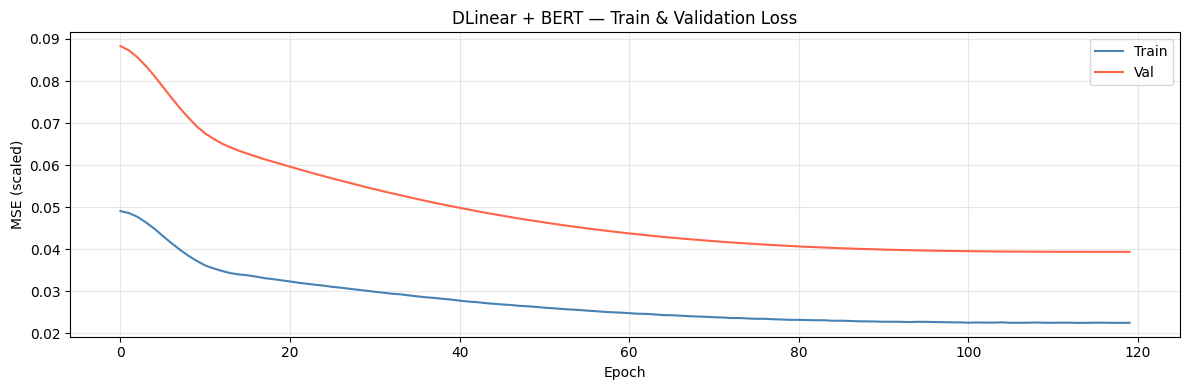

In [17]:
plt.figure(figsize=(12, 4))
plt.title('DLinear + BERT — Train & Validation Loss')
plt.plot(history['epoch'], history['train_loss'], label='Train', color='steelblue')
plt.plot(history['epoch'], history['val_loss'],   label='Val',   color='tomato')
plt.xlabel('Epoch')
plt.ylabel('MSE (scaled)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Test Evaluation (inverse-scaled)

Identical to stable nb cells 108-110.

In [18]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

test_preds, test_targets = [], []

with torch.no_grad():
    for batch in test_loader:
        X_num_b = batch[0].to(device)
        text_b  = {k: v.to(device) for k, v in batch[1].items()}
        targets = batch[2]
        with autocast():
            preds = model(X_num_b, text_b['input_ids'], text_b['attention_mask'])
        test_preds.extend(preds.cpu().numpy())    # list of (12,) arrays
        test_targets.extend(targets.numpy())      # list of (12,) arrays

# ── Reshape to (N, 12) ────────────────────────────────────────────────────────
test_preds   = np.array(test_preds)    # (N, 12)
test_targets = np.array(test_targets)  # (N, 12)

# ── Inverse transform — flatten to (N*12, 1), transform, reshape back ─────────
inv_preds   = target_scaler.inverse_transform(
                  test_preds.reshape(-1, 1)).reshape(-1, 12)    # (N, 12)
inv_targets = target_scaler.inverse_transform(
                  test_targets.reshape(-1, 1)).reshape(-1, 12)  # (N, 12)

# ── Aggregate metrics (inverse-scaled) ───────────────────────────────────────
mse_val  = mean_squared_error(inv_targets.flatten(), inv_preds.flatten())
mae_val  = mean_absolute_error(inv_targets.flatten(), inv_preds.flatten())
rmse_val = np.sqrt(mse_val)

print('=' * 60)
print(f'  DLinear + BERT  |  Test MSE : {mse_val:.4f}')
print(f'                  |  Test MAE : {mae_val:.4f}')
print(f'                  |  Test RMSE: {rmse_val:.4f}  (inverse-scaled)')
print(f'  DLinear alone   |  Test MSE : 1.6642')
print(f'  DSA (mean/best) |  Test MSE : 1.120 ± 0.096 / 0.9749')
print('=' * 60)

# ── Per-sample errors for Diebold-Mariano (inverse-scaled, shape (N,)) ────────
per_sample_mse   = ((inv_preds - inv_targets) ** 2).mean(axis=1)   # (N,)
per_horizon_mse  = ((inv_preds - inv_targets) ** 2).mean(axis=0)   # (12,)

np.save(f'{LOG_DIR}/errors_dlinear_bert.npy',  per_sample_mse)   # for DM test
np.save(f'{LOG_DIR}/horizon_dlinear_bert.npy', per_horizon_mse)  # for horizon plot
np.save(f'{LOG_DIR}/preds_dlinear_bert.npy',   inv_preds)        # full predictions
np.save(f'{LOG_DIR}/targets_dlinear_bert.npy', inv_targets)      # ground truth

# ── Per-horizon MSE print ─────────────────────────────────────────────────────
print('\nPer-horizon MSE (weeks 1-12):')
for h, hmse in enumerate(per_horizon_mse, 1):
    print(f'  Week {h:2d}: {hmse:.4f}')

  DLinear + BERT  |  Test MSE : 2.5916
                  |  Test MAE : 1.0290
                  |  Test RMSE: 1.6098  (inverse-scaled)
  DLinear alone   |  Test MSE : 1.6642
  DSA (mean/best) |  Test MSE : 1.120 ± 0.096 / 0.9749

Per-horizon MSE (weeks 1-12):
  Week  1: 1.5638
  Week  2: 1.8998
  Week  3: 2.0285
  Week  4: 2.3257
  Week  5: 2.4990
  Week  6: 2.7360
  Week  7: 2.8285
  Week  8: 2.9810
  Week  9: 3.0633
  Week 10: 3.0974
  Week 11: 3.0639
  Week 12: 3.0120


## 14. Prediction vs Ground Truth Plot

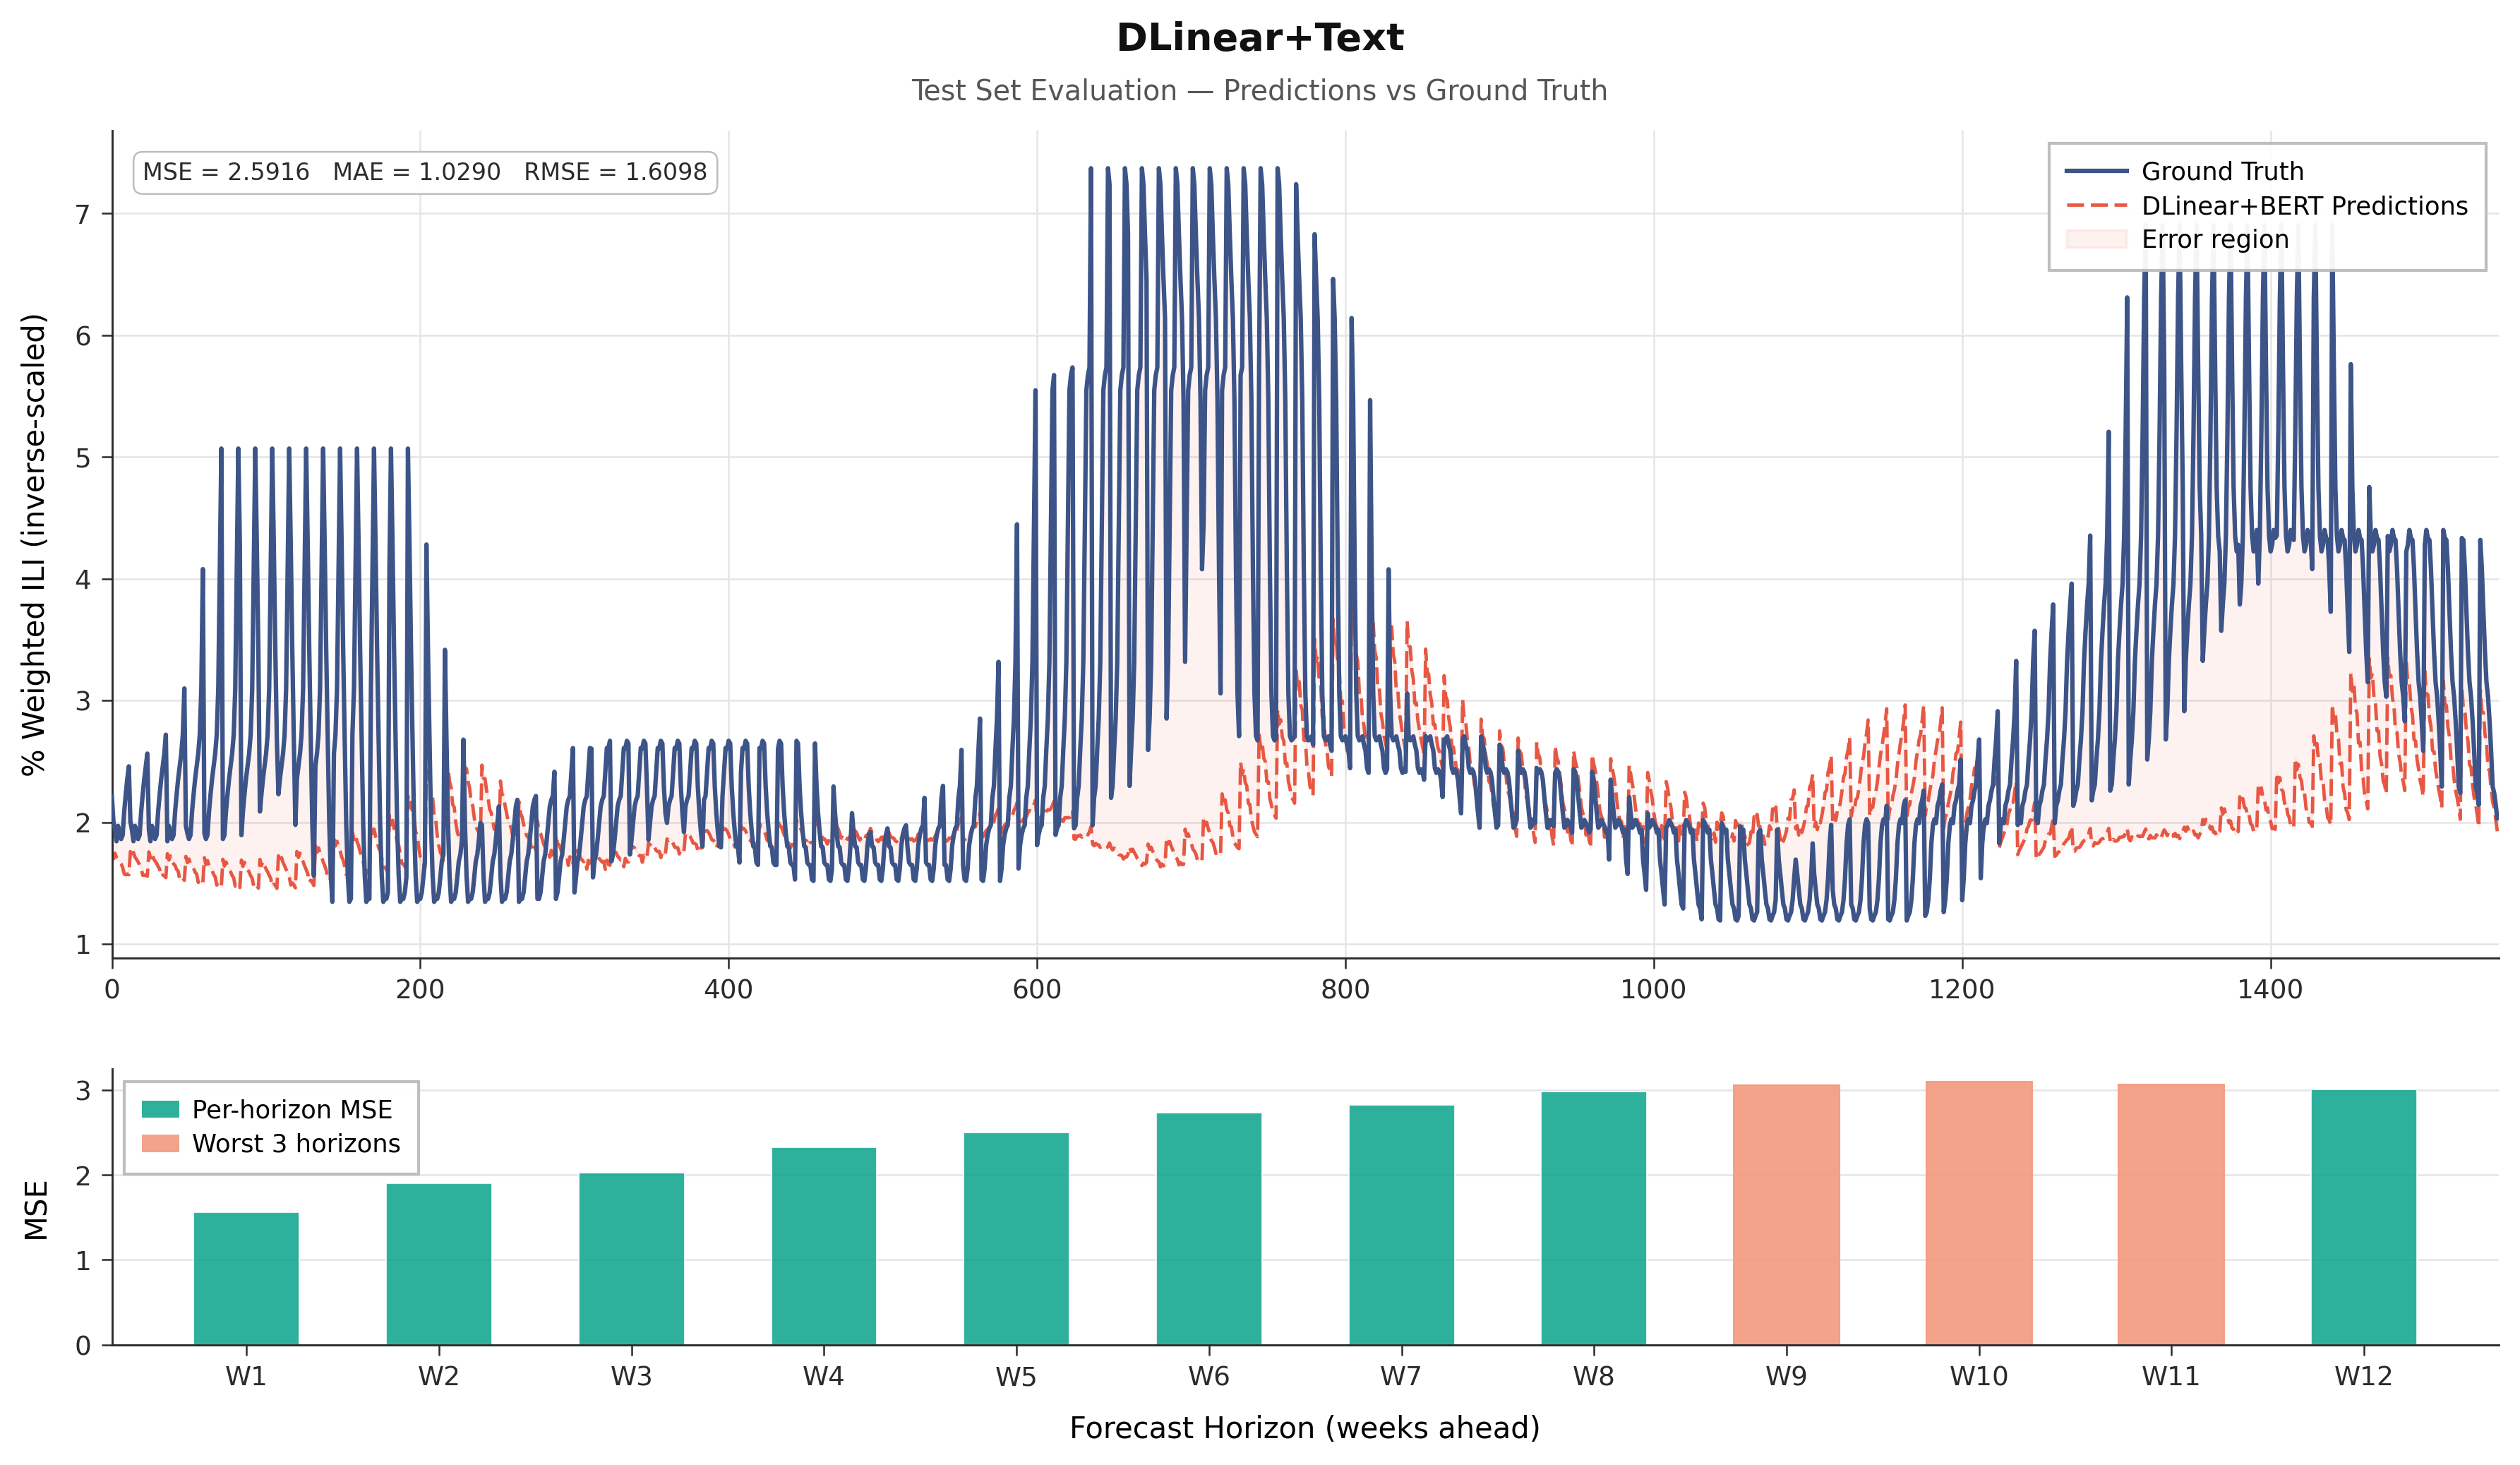

In [19]:
# ── NPG  palette ────────────────────────────────────
C_TRUTH  = '#3C5488'   # deep indigo   — ground truth
C_PRED   = '#E64B35'   # coral red     — predictions
C_FILL   = '#E64B35'   # error fill
C_BAR    = '#00A087'   # teal          — base bars
C_WORST  = '#F39B7F'   # soft salmon   — worst horizons
C_GRID   = '#E5E5E5'

mpl.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':          10,
    'axes.linewidth':     0.7,
    'axes.edgecolor':    '#2B2B2B',
    'axes.facecolor':    'white',
    'figure.facecolor':  'white',
    'xtick.major.width':  0.6, 'ytick.major.width':  0.6,
    'xtick.major.size':   3.5, 'ytick.major.size':   3.5,
    'xtick.direction':   'out', 'ytick.direction':   'out',
    'xtick.color':       '#2B2B2B', 'ytick.color':   '#2B2B2B',
    'legend.framealpha':  0.95, 'legend.edgecolor': '#BBBBBB',
    'legend.fancybox':    False,
})

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(12, 6.5), dpi=300,
    gridspec_kw={'height_ratios': [3, 1]}
)

# ── Two-line title: bold model name + lighter subtitle ────────────────────────
fig.text(0.5, 1.03, 'DLinear+Text',
         ha='center', va='bottom',
         fontsize=13, fontweight='bold', color='#111111')
fig.text(0.5, 0.995, 'Test Set Evaluation — Predictions vs Ground Truth',
         ha='center', va='bottom',
         fontsize=9.5, fontweight='normal', color='#555555')

# ── Panel 1 ───────────────────────────────────────────────────────────────────
flat_targets = inv_targets.flatten()   # (N*12,)
flat_preds   = inv_preds.flatten()     # (N*12,)
timesteps    = np.arange(len(flat_targets))
ax1.plot(timesteps, flat_targets,
         color=C_TRUTH, linewidth=1.5, alpha=1.0,
         label='Ground Truth', zorder=3)
ax1.plot(timesteps, flat_preds,
         color=C_PRED, linewidth=1.15, linestyle='--',
         dashes=(5, 2), alpha=0.92,
         label='DLinear+BERT Predictions', zorder=2)
ax1.fill_between(timesteps, flat_targets, flat_preds,
                 color=C_FILL, alpha=0.07, zorder=1, label='Error region')
ax1.set_ylabel('% Weighted ILI (inverse-scaled)', fontsize=10, labelpad=8)
ax1.set_xlim(0, len(flat_targets))
ax1.grid(True, color=C_GRID, linewidth=0.6, linestyle='-')
ax1.set_axisbelow(True)
ax1.spines[['top', 'right']].set_visible(False)
ax1.tick_params(axis='both', labelsize=9)
ax1.legend(loc='upper right', fontsize=8.5, handlelength=2.4,
           handletextpad=0.6, borderpad=0.7, labelspacing=0.4)
ax1.text(0.013, 0.963,
         f'MSE = {mse_val:.4f}   MAE = {mae_val:.4f}   RMSE = {rmse_val:.4f}',
         transform=ax1.transAxes, fontsize=8,
         verticalalignment='top', color='#2B2B2B',
         bbox=dict(boxstyle='round,pad=0.40', facecolor='white',
                   edgecolor='#BBBBBB', linewidth=0.6, alpha=0.97))

# ── Panel 2 ───────────────────────────────────────────────────────────────────
horizon_steps = np.arange(1, 13)
bars = ax2.bar(horizon_steps, per_horizon_mse,
               color=C_BAR, alpha=0.82, width=0.55,
               edgecolor='white', linewidth=0.5, zorder=2)
top3_idx = np.argsort(per_horizon_mse)[-3:]
for idx in top3_idx:
    bars[idx].set_color(C_WORST)
    bars[idx].set_alpha(0.92)
ax2.set_xlabel('Forecast Horizon (weeks ahead)', fontsize=10, labelpad=8)
ax2.set_ylabel('MSE', fontsize=10, labelpad=8)
ax2.set_xticks(horizon_steps)
ax2.set_xticklabels([f'W{h}' for h in horizon_steps], fontsize=8.5)
ax2.grid(axis='y', color=C_GRID, linewidth=0.6, linestyle='-')
ax2.set_axisbelow(True)
ax2.set_xlim(0.3, 12.7)
ax2.tick_params(axis='both', labelsize=9)
ax2.spines[['top', 'right']].set_visible(False)
ax2.legend(handles=[
    Patch(facecolor=C_BAR,   alpha=0.82, label='Per-horizon MSE'),
    Patch(facecolor=C_WORST, alpha=0.92, label='Worst 3 horizons'),
], fontsize=8.5, loc='upper left', handlelength=1.5,
   handletextpad=0.5, borderpad=0.7, labelspacing=0.4)

plt.tight_layout(h_pad=2.2)
plt.savefig(f'{LOG_DIR}/dlinear_bert_test_evaluation.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

## Notes

**What this model deliberately does NOT have (vs DSA):**

| Component | DSA | DLinear+BERT |
|---|---|---|
| Numerical encoder | Transformer | DLinear |
| Text encoder | BioLinkBERT | BioLinkBERT |
| Cross-modal attention (CMA) | Bidirectional | None |
| Temporal modeling on fused repr | Causal Transformer | None |
| Fusion | Concat + CMA + proj | Element-wise sum |

**Interpreting results:**
- If `DLinear+BERT MSE` < `DLinear MSE` → text adds value even with naive fusion
- If `DSA MSE` < `DLinear+BERT MSE` → CMA + temporal modeling adds value beyond naive fusion
- Both gaps together = your ablation story in the paper